# 09 — Paper Figures

Final publication-ready exports: one headline table + four figures, each saved as both PDF (vector, for the paper) and PNG (raster, for preview / Slack).

Consumes the production-sweep outputs (no prefix). Inputs:
- `results/predictions/pooled_allLeads.nc`
- `results/metrics/metrics_allLeads.csv`
- `results/logs/feature_status.csv`

Outputs:
- `results/figures/09_paper/headline_table.csv`  and  `headline_table.tex`
- `results/figures/09_paper/fig01_acc_vs_lead.{pdf,png}`
- `results/figures/09_paper/fig02_msss_bars.{pdf,png}`
- `results/figures/09_paper/fig03_spatial_skill.{pdf,png}`
- `results/figures/09_paper/fig04_feature_importance.{pdf,png}`

Typography is set once at the top via `rcParams`, so every figure inherits the same fonts / sizes. Editable PDF text (`pdf.fonttype=42`) so labels can be tweaked in Illustrator if needed.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from droughtmodel.utils import RESULTS_DIR
from droughtmodel import data as ddata
from droughtmodel import features as dfeat

# -------------------------------------------------------------------
# Paper-grade typography. Applied to every figure below.
# -------------------------------------------------------------------
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['DejaVu Sans', 'Arial', 'Helvetica'],
    'font.size':         10,
    'axes.titlesize':    11,
    'axes.labelsize':    10,
    'axes.linewidth':    0.8,
    'legend.fontsize':   8.5,
    'legend.frameon':    True,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'figure.dpi':        100,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'pdf.fonttype':      42,
    'ps.fonttype':       42,
})
sns.set_palette('tab10')

PAPER_DIR = RESULTS_DIR / 'figures' / '09_paper'
PAPER_DIR.mkdir(parents=True, exist_ok=True)

def save_paper(fig, name):
    """Save a figure as both PDF (vector) and PNG (raster) at 300 dpi."""
    fig.savefig(PAPER_DIR / f'{name}.pdf')
    fig.savefig(PAPER_DIR / f'{name}.png')
    print(f'  -> {(PAPER_DIR / name).relative_to(ROOT)}.{{pdf,png}}')

ds_preds   = xr.open_dataset(RESULTS_DIR / 'predictions' / 'pooled_allLeads.nc')
metrics_df = pd.read_csv(RESULTS_DIR / 'metrics' / 'metrics_allLeads.csv')
feat       = pd.read_csv(RESULTS_DIR / 'logs' / 'feature_status.csv')

MODEL_ORDER = ['climatology', 'persistence', 'ar', 'ols', 'ridge', 'lasso', 'elasticnet', 'rf', 'xgboost']
BASELINE_NAMES = {'climatology', 'persistence', 'ar'}
models_present = [m for m in MODEL_ORDER if m in metrics_df['model'].unique()]
leads = sorted(metrics_df['lead'].unique())

winter = metrics_df.query("evaluation_window == 'winter_only'")

ml_models = [m for m in models_present if m not in BASELINE_NAMES]
best_ml = (winter
    .query("model in @ml_models and metric == 'msss_vs_climatology'")
    .groupby('model')['value'].mean().idxmax())

print(f'Production data loaded:  {len(metrics_df)} metric rows, {len(feat)} feature-status rows')
print(f'Models:                  {models_present}')
print(f'Leads:                   {leads}')
print(f'Best ML model (by mean MSSS-vs-clim): {best_ml!r}')
print(f'Output dir:              {PAPER_DIR.relative_to(ROOT)}')

Production data loaded:  324 metric rows, 5409 feature-status rows
Models:                  ['climatology', 'persistence', 'ar', 'ols', 'ridge', 'lasso', 'elasticnet', 'rf', 'xgboost']
Leads:                   [np.int64(1), np.int64(3), np.int64(6)]
Best ML model (by mean MSSS-vs-clim): 'rf'
Output dir:              results/figures/09_paper


## Table 1 — Headline skill (LaTeX-ready)

Model x lead grid for the six headline metrics. Winter-only pool. `*` marks 95 % bootstrap CI excluding zero (significance, higher-is-better metrics only).

In [2]:
HIGHER_IS_BETTER = {'pearson_r', 'acc', 'msss_vs_climatology', 'msss_vs_persistence'}
HEADLINE_METRICS = ['mae', 'rmse', 'pearson_r', 'acc', 'msss_vs_climatology', 'msss_vs_persistence']
METRIC_LABELS = {
    'mae': 'MAE', 'rmse': 'RMSE', 'pearson_r': 'r',
    'acc': 'ACC', 'msss_vs_climatology': 'MSSS\\textsubscript{clim}',
    'msss_vs_persistence': 'MSSS\\textsubscript{pers}',
}

def _sig(row):
    if row['metric'] not in HIGHER_IS_BETTER: return False
    if pd.isna(row['ci_lower']) or pd.isna(row['ci_upper']): return False
    return bool(row['ci_lower'] > 0 or row['ci_upper'] < 0)

def _fmt(row):
    v = row['value']
    if pd.isna(v): return '---'
    return f'{v:.2f}' + ('*' if _sig(row) else '')

tab = winter.copy()
tab['fmt'] = tab.apply(_fmt, axis=1)
table = (tab.pivot(index=['model', 'lead'], columns='metric', values='fmt')
            .loc[[(m, L) for m in models_present for L in leads]]
            [HEADLINE_METRICS])
table.columns.name = None

table.to_csv(PAPER_DIR / 'headline_table.csv')

latex_table = table.rename(columns=METRIC_LABELS).to_latex(
    escape=False, na_rep='---',
    caption='Headline skill on the pooled winter target months (Nov-Feb, 2000-2024). '
            '$^*$ denotes a 95\\,\\% block-bootstrap CI excluding zero '
            '(higher-is-better metrics only).',
    label='tab:headline_skill',
    column_format='ll' + 'r' * len(HEADLINE_METRICS),
)
(PAPER_DIR / 'headline_table.tex').write_text(latex_table)
print('  -> headline_table.{csv,tex}')

table

  -> headline_table.{csv,tex}


mae  rmse pearson_r    acc msss_vs_climatology  \
model       lead                                                    
climatology 1     0.83  0.99    -0.12*    ---                0.00   
            3     0.83  1.00    -0.10*    ---                0.00   
            6     0.87  1.03    -0.20*    ---                0.00   
persistence 1     0.55  0.71     0.72*  0.72*               0.49*   
            3     1.08  1.32      0.02   0.02              -0.74*   
            6     1.00  1.27      0.14   0.15              -0.50*   
ar          1     0.51  0.62     0.77*  0.77*               0.61*   
            3     0.82  0.99     -0.04   0.10               0.03*   
            6     0.85  1.01      0.04  0.28*               0.04*   
ols         1     0.46  0.57     0.81*  0.81*               0.67*   
            3     0.83  1.00     -0.00   0.03                0.00   
            6     0.86  1.03      0.01   0.09                0.01   
ridge       1     0.46  0.57     0.81*  0.81*               0.67*   
            3     0.83  1.00      0.00   0.04                0.00   
            6     0.86  1.03      0.02   0.09                0.02   
lasso       1     0.45  0.55     0.82*  0.82*               0.69*   
            3     0.83  1.00     -0.09   0.01                0.01   
            6     0.85  1.01      0.05  0.24*               0.04*   
elasticnet  1     0.45  0.56     0.82*  0.82*               0.68*   
            3     0.83  1.00     -0.10   0.01                0.01   
            6     0.85  1.01      0.04  0.21*               0.05*   
rf          1     0.47  0.56     0.81*  0.82*               0.68*   
            3     0.81  0.98      0.08   0.11                0.04   
            6     0.85  1.01      0.04   0.16                0.04   
xgboost     1     0.46  0.55     0.82*  0.82*               0.69*   
            3     0.86  1.06     -0.08  -0.07               -0.11   
            6     0.83  1.00      0.14  0.21*               0.07*   

                 msss_vs_persistence  
model       lead                      
climatology 1                 -0.96*  
            3                  0.43*  
            6                  0.33*  
persistence 1                   0.00  
            3                   0.00  
            6                   0.00  
ar          1                  0.23*  
            3                  0.44*  
            6                  0.36*  
ols         1                  0.36*  
            3                  0.43*  
            6                  0.34*  
ridge       1                  0.36*  
            3                  0.43*  
            6                  0.34*  
lasso       1                  0.40*  
            3                  0.43*  
            6                  0.36*  
elasticnet  1                  0.38*  
            3                  0.43*  
            6                  0.36*  
rf          1                  0.37*  
            3                  0.45*  
            6                  0.36*  
xgboost     1                  0.39*  
            3                  0.36*  
            6                  0.38*

## Figure 1 — Skill vs lead

ACC and MSSS-vs-climatology as functions of forecast lead. Each model is one line; error bars are the 95 % block-bootstrap CI. Climatology is omitted from the ACC panel (zero-variance forecast then ACC undefined).

  -> results/figures/09_paper/fig01_acc_vs_lead.{pdf,png}


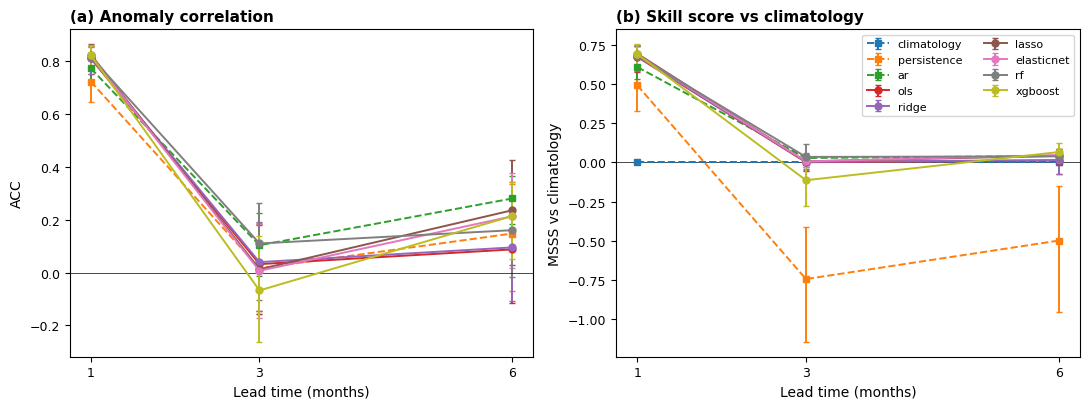

In [3]:
colors = dict(zip(MODEL_ORDER, sns.color_palette('tab10', n_colors=len(MODEL_ORDER))))
linestyles = {**{m: '--' for m in BASELINE_NAMES}, **{m: '-' for m in ml_models}}
markers = {**{m: 's' for m in BASELINE_NAMES}, **{m: 'o' for m in ml_models}}

def _line(ax, metric_name, ylabel, drop_models=()):
    sub = winter[winter['metric'] == metric_name]
    for mdl in models_present:
        if mdl in drop_models:
            continue
        s = sub[sub['model'] == mdl].sort_values('lead')
        if s['value'].isna().all():
            continue
        yerr_lo = s['value'].values - s['ci_lower'].values
        yerr_hi = s['ci_upper'].values - s['value'].values
        ax.errorbar(
            s['lead'], s['value'], yerr=[yerr_lo, yerr_hi],
            marker=markers.get(mdl, 'o'), markersize=5,
            capsize=2.5, linewidth=1.4, linestyle=linestyles.get(mdl, '-'),
            color=colors.get(mdl, None), label=mdl,
        )
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xticks(leads)
    ax.set_xlabel('Lead time (months)')
    ax.set_ylabel(ylabel)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
_line(axes[0], 'acc', 'ACC', drop_models={'climatology'})
_line(axes[1], 'msss_vs_climatology', 'MSSS vs climatology')
axes[0].set_title('(a) Anomaly correlation', loc='left', fontweight='bold', fontsize=11)
axes[1].set_title('(b) Skill score vs climatology', loc='left', fontweight='bold', fontsize=11)
axes[1].legend(loc='upper right', ncol=2, fontsize=8)
plt.tight_layout()
save_paper(fig, 'fig01_acc_vs_lead')
plt.show()

## Figure 2 — Skill scores by model

Bar chart of MSSS-vs-climatology and MSSS-vs-persistence per (model, lead) on the winter pool. Bars above zero beat the reference. Error bars are 95 % block-bootstrap CIs.

  -> results/figures/09_paper/fig02_msss_bars.{pdf,png}


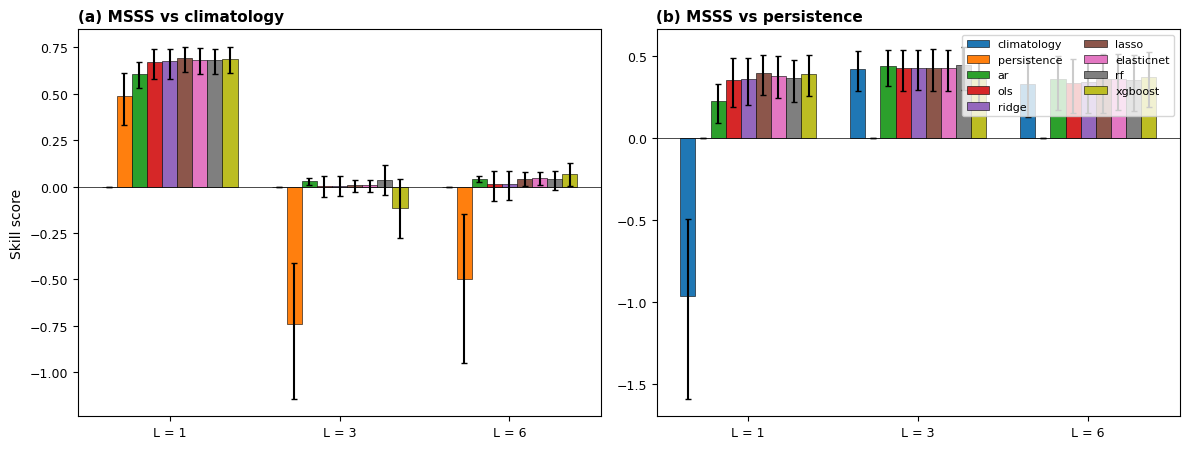

In [4]:
def _bars(ax, metric_name, title):
    sub = winter[winter['metric'] == metric_name]
    n = len(models_present)
    width = 0.8 / n
    x = np.arange(len(leads))
    for i, mdl in enumerate(models_present):
        s = sub[sub['model'] == mdl].set_index('lead').reindex(leads)
        ye_lo = s['value'].values - s['ci_lower'].values
        ye_hi = s['ci_upper'].values - s['value'].values
        ax.bar(
            x + (i - n / 2 + 0.5) * width, s['value'].values,
            yerr=np.vstack([ye_lo, ye_hi]),
            capsize=2.0, width=width,
            edgecolor='black', linewidth=0.4,
            color=colors.get(mdl, None), label=mdl,
        )
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels([f'L = {L}' for L in leads])
    ax.set_title(title, loc='left', fontweight='bold', fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
_bars(axes[0], 'msss_vs_climatology', '(a) MSSS vs climatology')
_bars(axes[1], 'msss_vs_persistence', '(b) MSSS vs persistence')
axes[0].set_ylabel('Skill score')
axes[1].legend(loc='upper right', ncol=2, fontsize=8)
plt.tight_layout()
save_paper(fig, 'fig02_msss_bars')
plt.show()

## Figure 3 — Spatial skill story

Per-cell ACC over the winter pool. Three rows compare the strongest baseline at each lead, the best ML model overall (selected dynamically — see setup cell output), and their difference. The Delta-ACC row is the cleanest 'where does ML add value?' diagnostic — red regions are where the ML model beats the baseline.

/opt/anaconda3/envs/droughtforecast/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_18804/2689054534.py:11: RuntimeWarning: Mean of empty slice
  num = np.nanmean((pa - np.nanmean(pa, axis=0)) * (ta - np.nanmean(ta, axis=0)), axis=0)
/opt/anaconda3/envs/droughtforecast/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  -> results/figures/09_paper/fig03_spatial_skill.{pdf,png}


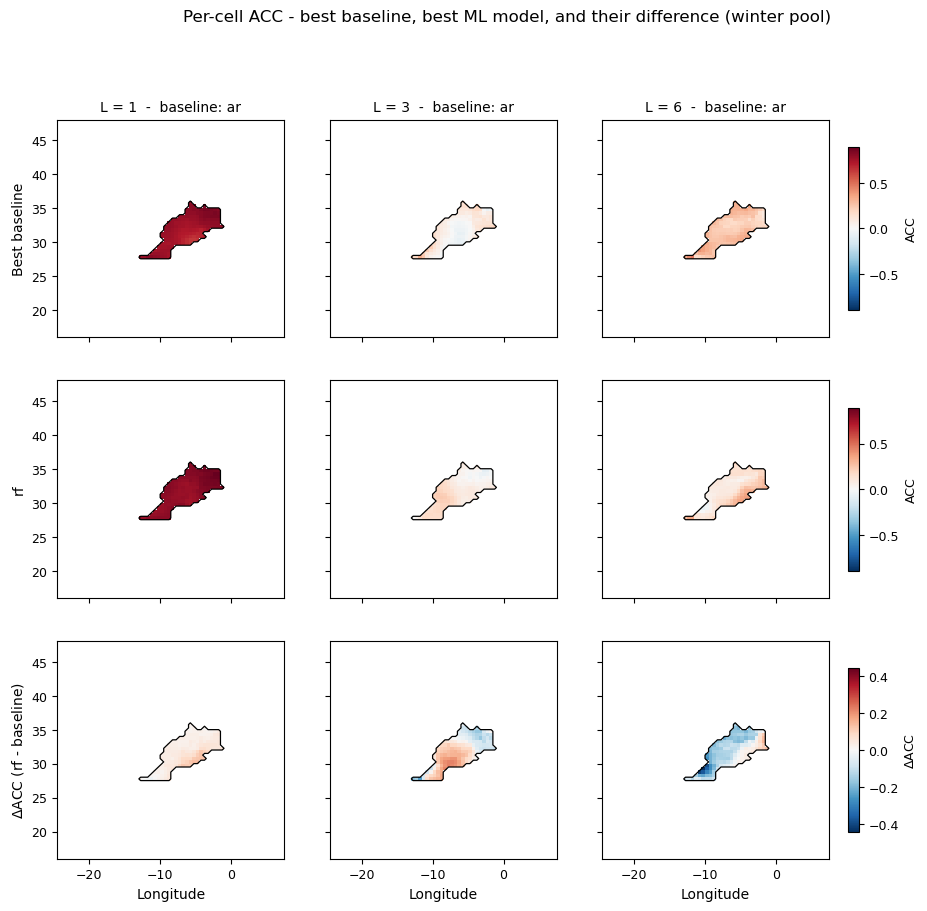


Morocco-mean Delta-ACC (ML - baseline):
  L = 1  baseline=ar           mean = +0.045, %cells positive = 4%
  L = 3  baseline=ar           mean = +0.036, %cells positive = 2%
  L = 6  baseline=ar           mean = -0.109, %cells positive = 1%


In [5]:
data_cfg = ddata.load_config(ROOT / 'configs' / 'data.yaml')
feat_cfg = dfeat.load_features_config(ROOT / 'configs' / 'features.yaml')
raw_datasets = ddata.load_all(data_cfg)
template = dfeat.gather_predictor('spei3', raw_datasets)
morocco_mask = dfeat.load_region_mask(feat_cfg['region_mask']['path'], template, name='morocco')
lat, lon = morocco_mask['lat'], morocco_mask['lon']

def per_cell_acc(pred, truth, clim, winter_mask, mask):
    yp, yt, yc = pred[winter_mask], truth[winter_mask], clim[winter_mask]
    pa, ta = yp - yc, yt - yc
    num = np.nanmean((pa - np.nanmean(pa, axis=0)) * (ta - np.nanmean(ta, axis=0)), axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        a = num / (np.nanstd(pa, axis=0) * np.nanstd(ta, axis=0))
    a[~mask.values] = np.nan
    return a

time_idx = pd.DatetimeIndex(ds_preds['time'].values)
winter_mask = np.isin(time_idx.month, [11, 12, 1, 2])

best_baseline_per_lead = {}
for L in leads:
    vals = (winter
        .query("model in @BASELINE_NAMES and model != 'climatology' and lead == @L and metric == 'msss_vs_climatology'")
        .set_index('model')['value'])
    best_baseline_per_lead[L] = vals.idxmax() if not vals.empty else 'persistence'

panels = {}
for L in leads:
    base = best_baseline_per_lead[L]
    truth = ds_preds['truth'].sel(lead=L).values
    clim = ds_preds['pred_climatology'].sel(lead=L).values
    p_base = ds_preds[f'pred_{base}'].sel(lead=L).values
    p_ml = ds_preds[f'pred_{best_ml}'].sel(lead=L).values
    acc_base = per_cell_acc(p_base, truth, clim, winter_mask, morocco_mask)
    acc_ml = per_cell_acc(p_ml, truth, clim, winter_mask, morocco_mask)
    panels[L] = {'base': acc_base, 'ml': acc_ml, 'diff': acc_ml - acc_base, 'base_name': base}

vmax_acc = float(np.nanmax(np.abs([panels[L][k] for L in leads for k in ('base', 'ml')]))) or 1.0
vmax_diff = float(np.nanmax(np.abs([panels[L]['diff'] for L in leads]))) or 0.1

fig, axes = plt.subplots(3, len(leads), figsize=(4.0 * len(leads), 9.6), sharex=True, sharey=True)
row_labels = ['Best baseline', best_ml, f'$\\Delta$ACC ({best_ml} - baseline)']
row_keys = ['base', 'ml', 'diff']
row_vmax = [vmax_acc, vmax_acc, vmax_diff]
row_cbar_label = ['ACC', 'ACC', '$\\Delta$ACC']
ims = [None, None, None]
for r, (label, key, vm) in enumerate(zip(row_labels, row_keys, row_vmax)):
    for c, L in enumerate(leads):
        ax = axes[r, c]
        da = xr.DataArray(panels[L][key], dims=('lat', 'lon'), coords={'lat': lat, 'lon': lon})
        im = da.plot(ax=ax, cmap='RdBu_r', vmin=-vm, vmax=vm, add_colorbar=False)
        ims[r] = im
        morocco_mask.plot.contour(ax=ax, levels=[0.5], colors='black', linewidths=0.9, add_colorbar=False)
        if r == 0:
            ax.set_title(f'L = {L}  -  baseline: {panels[L]["base_name"]}', fontsize=10)
        else:
            ax.set_title('')
        ax.set_xlabel('Longitude' if r == 2 else '')
        ax.set_ylabel(label if c == 0 else '')

for r, label in enumerate(row_cbar_label):
    cbar = fig.colorbar(ims[r], ax=axes[r, :].tolist(), shrink=0.75, pad=0.02, aspect=15)
    cbar.set_label(label, fontsize=9)

fig.suptitle('Per-cell ACC - best baseline, best ML model, and their difference (winter pool)', y=0.995)
save_paper(fig, 'fig03_spatial_skill')
plt.show()

print('\nMorocco-mean Delta-ACC (ML - baseline):')
for L in leads:
    d = panels[L]['diff']
    print(f'  L = {L}  baseline={panels[L]["base_name"]:<11}  mean = {float(np.nanmean(d)):+.3f}, '
          f'%cells positive = {float(np.nanmean(d > 0)) * 100:.0f}%')

## Figure 4 — Feature interpretation

Three-panel summary of what the models actually *use*: (a) ElasticNet retention across 5 folds (which features survive the L1 penalty most consistently), (b) RF top-15 Gini importance at the headline lead, (c) XGBoost top-15 gain at the headline lead.

Note: built-in tree importances under-credit correlated features (multicollinearity, see notebook 08 closing notes). For paper-quality interpretation, swap in permutation/SHAP if/when the pipeline is extended to save fitted models.

  -> results/figures/09_paper/fig04_feature_importance.{pdf,png}


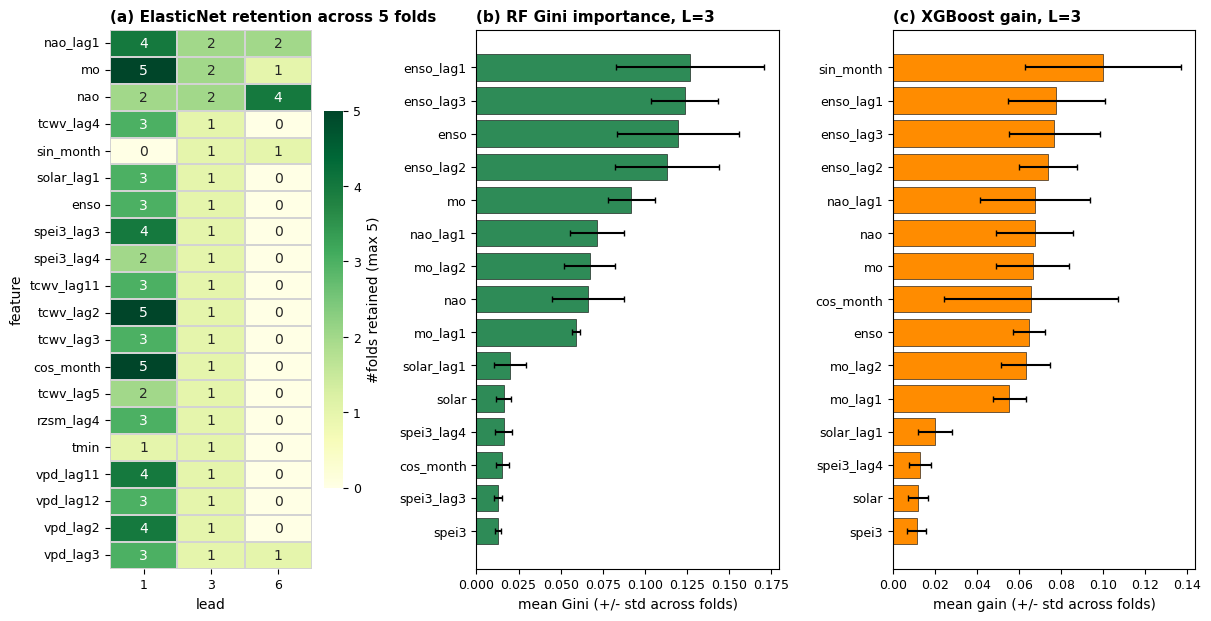

In [6]:
HEADLINE_LEAD = 3 if 3 in leads else int(np.median(leads))
n_folds = feat[feat['kind'] == 'coef']['fold'].nunique()
TOP_N = 15

en = feat[feat['model'] == 'elasticnet']
if en.empty:
    en = feat[feat['model'] == 'lasso']
    en_label = 'Lasso'
else:
    en_label = 'ElasticNet'
ret = (en.assign(retained_int=en['retained'].astype(int))
         .groupby(['feature', 'lead'])['retained_int']
         .sum().unstack('lead', fill_value=0))
sort_key = ret[HEADLINE_LEAD] if HEADLINE_LEAD in ret.columns else ret.iloc[:, 0]
ret = ret.loc[sort_key.sort_values(ascending=False).index].head(TOP_N + 5)

rf_top = (feat.query("model == 'rf' and lead == @HEADLINE_LEAD")
              .groupby('feature')['importance']
              .agg(['mean', 'std'])
              .sort_values('mean', ascending=False)
              .head(TOP_N))

xgb_top = (feat.query("model == 'xgboost' and lead == @HEADLINE_LEAD")
               .groupby('feature')['importance']
               .agg(['mean', 'std'])
               .sort_values('mean', ascending=False)
               .head(TOP_N))

fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.2, 1.2], wspace=0.4)
ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])
ax_c = fig.add_subplot(gs[2])

sns.heatmap(
    ret, ax=ax_a, cmap='YlGn', vmin=0, vmax=n_folds,
    annot=True, fmt='d', linewidths=0.3, linecolor='lightgray',
    cbar_kws={'label': f'#folds retained (max {n_folds})', 'shrink': 0.7},
)
ax_a.set_title(f'(a) {en_label} retention across {n_folds} folds', loc='left', fontweight='bold', fontsize=11)
ax_a.set_xlabel('lead'); ax_a.set_ylabel('feature')

ax_b.barh(rf_top.index[::-1], rf_top['mean'][::-1], xerr=rf_top['std'][::-1],
          color='seagreen', edgecolor='black', linewidth=0.4, capsize=2)
ax_b.set_title(f'(b) RF Gini importance, L={HEADLINE_LEAD}', loc='left', fontweight='bold', fontsize=11)
ax_b.set_xlabel('mean Gini (+/- std across folds)')

ax_c.barh(xgb_top.index[::-1], xgb_top['mean'][::-1], xerr=xgb_top['std'][::-1],
          color='darkorange', edgecolor='black', linewidth=0.4, capsize=2)
ax_c.set_title(f'(c) XGBoost gain, L={HEADLINE_LEAD}', loc='left', fontweight='bold', fontsize=11)
ax_c.set_xlabel('mean gain (+/- std across folds)')

save_paper(fig, 'fig04_feature_importance')
plt.show()

## Notes

**Files produced** (in `results/figures/09_paper/`):
- `headline_table.csv` — paste-friendly
- `headline_table.tex` — drop straight into the paper LaTeX source (uses `\caption`, `\label{tab:headline_skill}`)
- `fig01_acc_vs_lead.{pdf,png}` — ACC and MSSS-vs-clim vs lead
- `fig02_msss_bars.{pdf,png}` — skill scores by model
- `fig03_spatial_skill.{pdf,png}` — per-cell ACC: baseline / best ML / difference
- `fig04_feature_importance.{pdf,png}` — L1 retention + tree importances

**Best ML model is selected dynamically** (mean MSSS-vs-clim across leads, winter pool) — currently resolves to the model printed in the setup cell. If you want to fix one specific model regardless of metric (e.g. always XGBoost for the spatial figure), edit the `best_ml = ...` line in the setup cell.

**For Overleaf**: drop `headline_table.tex` straight in, and `\includegraphics{fig01_acc_vs_lead.pdf}` (etc.) inside `\begin{figure}` blocks. The 300 dpi PDFs are vector — they'll scale to any column width without artefacts. `pdf.fonttype=42` keeps the text editable in Illustrator if last-minute label tweaks are needed.

**Permutation / SHAP for the paper**: panel (b) and (c) of Figure 4 use built-in importances (Gini, gain), which are known to under-credit correlated features. A cleaner version replaces these with permutation importance (RF) and TreeSHAP mean(|SHAP|) (XGBoost) on the OOS test slice. The infrastructure for both is already in `droughtmodel/selection.py`; the missing piece is having the pipeline save fitted models so post-hoc importance can be computed without re-fitting. Queued as a Phase 12 polish.